# Impact of Screen Time on Sleep Quality and Stress Levels  
### A Data-Driven Regression Analysis 
#### Group: 6 Harshita(2333317), Heer(2333318), Polaki Mythri(2333438), Saumya(2333448)


![Introduction Image](Untitled_design.jpg)

## Introduction

The rapid proliferation of smartphones and social media platforms has fundamentally altered daily routines, particularly among students and young adults. While digital technologies offer convenience and connectivity, excessive screen usage, especially during late evening hours has been associated with disrupted sleep patterns and declining mental well-being. Exposure to blue light emitted by screens suppresses melatonin production, thereby delaying sleep onset and reducing overall sleep duration (Chang et al., 2015).

Sleep deprivation has been widely recognized as a significant contributor to psychological stress and emotional dysregulation. Individuals experiencing inadequate or irregular sleep are more vulnerable to heightened stress levels, anxiety, and reduced cognitive performance (Pilcher & Huffcutt, 1996). The tendency to prioritize screen-based activities over adequate rest has therefore emerged as a growing public health concern.

## Problem Statement & Background

Despite increasing awareness of the importance of adequate sleep for mental and physical health, excessive smartphone and social media usage continues to rise among young adults. Many individuals engage in prolonged screen exposure late at night, often at the expense of sleep duration and quality. This behavioral pattern has raised concerns regarding its potential contribution to elevated stress levels and declining mental well-being.

Although existing literature highlights associations between screen exposure, sleep disruption, and stress, there remains a need for empirical analysis using contemporary, real-world data. In particular, the indirect pathway through which screen time affects stress via sleep deprivation is insufficiently explored in applied student-level datasets. This study addresses this gap by quantitatively analyzing the relationship between screen time, sleep duration, and stress levels using statistical methods.

## Hypotheses

- **H1:** Higher daily screen time is associated with shorter sleep duration among young adults.
- **H2:** Shorter sleep duration is associated with higher perceived stress levels.
- **H3:** Screen time has an indirect positive effect on stress levels through reduced sleep duration.

## Methodology

This study adopts a quantitative research design to analyze the relationship between screen time, sleep duration, and stress levels among young adults. The analysis is conducted using secondary data containing self-reported measures of daily screen usage, average sleep duration, and perceived stress levels.

Descriptive statistics are initially employed to understand the distribution and central tendencies of the key variables. This is followed by correlation analysis to examine the strength and direction of associations between screen time, sleep, and stress. Regression analysis is then used to assess the predictive impact of screen time and sleep duration on stress levels, allowing for clearer interpretation of direct and indirect relationships.

All data cleaning, visualization, and statistical modeling are performed using Python libraries such as pandas, matplotlib, seaborn, and statsmodels. The methodology ensures reproducibility and transparency, with each analytical step clearly documented within the Jupyter Notebook.

<h2>Importing the libraries and data</h2>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("Dataset.csv")

<h2>Exploring the data</h2>

In [ ]:
df.head()

,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
0,U1,58,Male,Professional,Android,1.3,6.7,6,8.8,4,42,1,8.7
1,U2,25,Male,Professional,Android,1.2,1.5,5,6.4,1,51,3,5.1
2,U3,19,Male,Student,iOS,5.3,5.7,5,9.0,4,14,5,6.3
3,U5,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3,37,5,9.9
4,U7,26,Male,Student,iOS,5.6,6.1,8,6.7,3,5,3,2.9


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    50 non-null     object 
 1   Age                        50 non-null     int64  
 2   Gender                     50 non-null     object 
 3   Occupation                 50 non-null     object 
 4   Device_Type                50 non-null     object 
 5   Daily_Phone_Hours          50 non-null     float64
 6   Social_Media_Hours         50 non-null     float64
 7   Work_Productivity_Score    50 non-null     int64  
 8   Sleep_Hours                50 non-null     float64
 9   Stress_Level               50 non-null     int64  
 10  App_Usage_Count            50 non-null     int64  
 11  Caffeine_Intake_Cups       50 non-null     int64  
 12  Weekend_Screen_Time_Hours  50 non-null     float64
dtypes: float64(4), int64(5), object(4)
memory usage: 5.2

In [ ]:
df.describe()

,Age,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,36.220000,6.364000,4.142000,5.580000,6.474000,5.620000,32.300000,3.200000,7.642000
std,12.316059,3.533153,2.034608,2.956073,1.556397,3.083134,16.939568,2.147614,3.486598
min,18.000000,1.100000,0.600000,1.000000,4.100000,1.000000,5.000000,0.000000,2.100000
25%,25.000000,3.425000,2.325000,3.000000,5.100000,3.000000,17.000000,1.000000,5.100000
50%,34.000000,5.700000,4.450000,5.500000,6.400000,5.000000,34.500000,3.000000,6.950000
75%,45.500000,9.700000,5.975000,8.000000,7.875000,8.000000,45.250000,5.000000,10.250000
max,59.000000,11.800000,7.500000,10.000000,9.000000,10.000000,59.000000,6.000000,14.000000


Check Missing Values

In [ ]:
df.isnull().sum()           #There are no null values

User_ID                      0
Age                          0
Gender                       0
Occupation                   0
Device_Type                  0
Daily_Phone_Hours            0
Social_Media_Hours           0
Work_Productivity_Score      0
Sleep_Hours                  0
Stress_Level                 0
App_Usage_Count              0
Caffeine_Intake_Cups         0
Weekend_Screen_Time_Hours    0
dtype: int64

Incase if a null value is found, fill them with mean values

In [ ]:
# df.fillna(df.mean(), inplace=True)                 #Uncomment it and run

Check Duplicate Rows

In [ ]:
print(df.duplicated().sum())                #Showing 0 means no duplicate values

0


Incase duplicate values are found, remove them to make data consistent and not skewed.

In [ ]:
# df = df.drop_duplicates()              #Uncomment it and run

User_ID does not contribute to behavioral patterns and was removed.

In [ ]:
df = df.drop(columns=['User_ID'])

Check Data Types

In [ ]:
df.dtypes

Age                            int64
Gender                        object
Occupation                    object
Device_Type                   object
Daily_Phone_Hours            float64
Social_Media_Hours           float64
Work_Productivity_Score        int64
Sleep_Hours                  float64
Stress_Level                   int64
App_Usage_Count                int64
Caffeine_Intake_Cups           int64
Weekend_Screen_Time_Hours    float64
dtype: object

If there is any column which is needed for calculation (must be numeric) and isn't numeric then convert it to numeric.

In [ ]:
# df['Column_name'] = pd.to_numeric(df['Column_name'])           #Uncomment it and run

<h3>Outlier Detection</h3>

<h3>BoxPlots</h3>

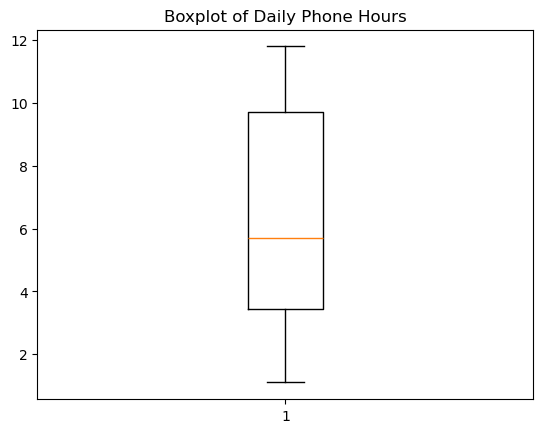

In [ ]:
plt.boxplot(df['Daily_Phone_Hours'])
plt.title("Boxplot of Daily Phone Hours")
plt.show()

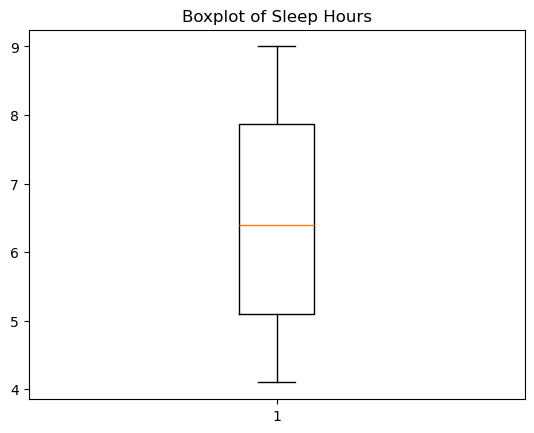

In [ ]:
plt.boxplot(df['Sleep_Hours'])
plt.title("Boxplot of Sleep Hours")
plt.show()

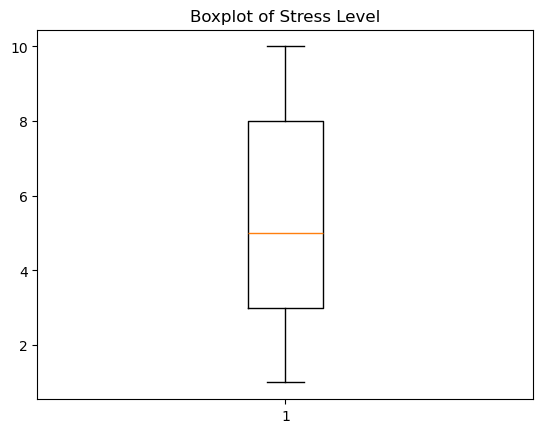

In [ ]:
plt.boxplot(df['Stress_Level'])
plt.title("Boxplot of Stress Level")
plt.show()

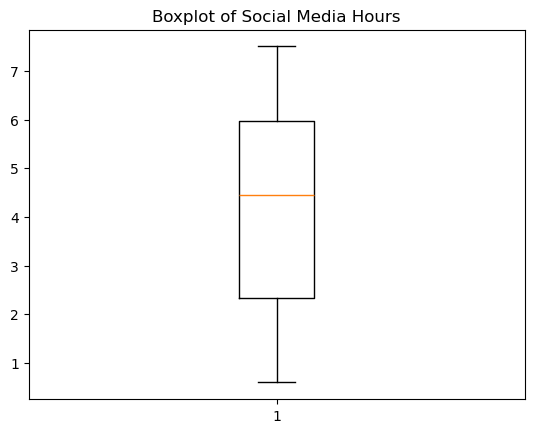

In [ ]:
plt.boxplot(df['Social_Media_Hours'])
plt.title("Boxplot of Social Media Hours")
plt.show()

<h3><b>Outlier detection was performed using boxplots for Daily Phone Hours, Sleep Hours, Stress Level, and Social Media Hours.
No significant outliers were observed in any of the variables, as no extreme values were present outside the whiskers.
Therefore, no data points were removed and the dataset was retained in its original form.</b></h3>

<h3>Correlation Matrix</h3>

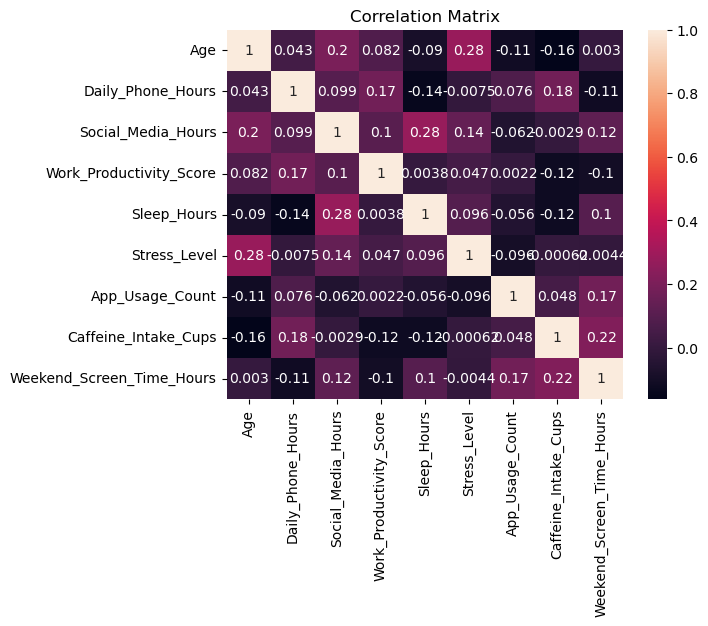

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

<h3>Relationship #1 : Daily Phone Hours vs Sleep Hours</h3>

Daily phone usage shows a weak negative correlation with sleep hours (-0.14), indicating that higher phone usage is associated with slightly reduced sleep duration.

<h3>Relationship #2 : Sleep Hours vs Stress Level</h3>

Sleep hours and stress level show very weak correlation (0.096), suggesting no strong relationship between sleep and stress in this dataset.

<h3>Relationship #3 : Daily Phone Hours vs Stress Level</h3>

Daily phone hours and stress level show almost no correlation (-0.007), indicating that phone usage does not directly influence stress levels.

<p><b>Overall, most relationships between variables are weak, indicating limited linear dependence.</b></p>

<h3>Scatter Plots</h3>

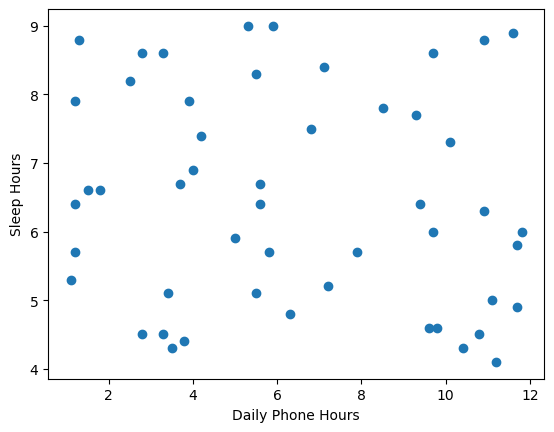

In [ ]:
plt.scatter(df['Daily_Phone_Hours'], df['Sleep_Hours'])
plt.xlabel("Daily Phone Hours")
plt.ylabel("Sleep Hours")
plt.show()

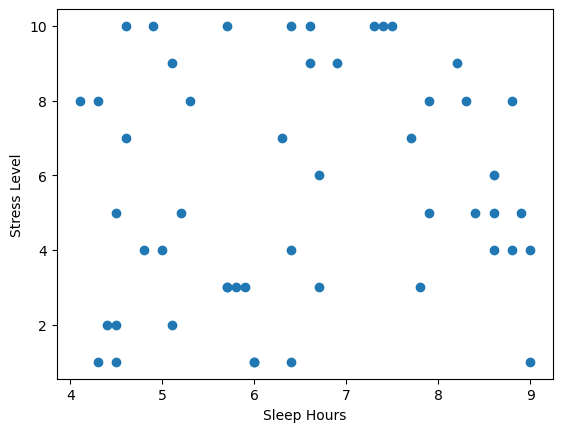

In [ ]:
plt.scatter(df['Sleep_Hours'], df['Stress_Level'])
plt.xlabel("Sleep Hours")
plt.ylabel("Stress Level")
plt.show()

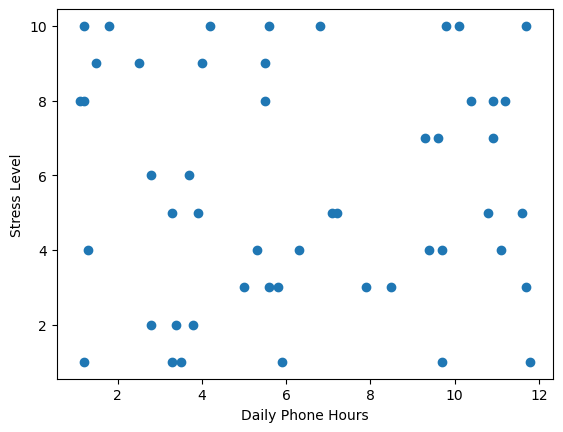

In [ ]:
plt.scatter(df['Daily_Phone_Hours'], df['Stress_Level'])
plt.xlabel("Daily Phone Hours")
plt.ylabel("Stress Level")
plt.show()

<h3>Scatter plots were used to visualize relationships between key variables.</h3>

<ul>
<li>The relationship between daily phone hours and stress level shows no clear pattern, indicating that phone usage does not significantly influence stress.</li>

<li>The scatter plot between sleep hours and stress level also shows no strong relationship, as stress values are widely distributed across all sleep durations.</li>

<li>The relationship between daily phone hours and sleep hours shows a slight negative trend, suggesting that increased phone usage may be associated with reduced sleep duration, although the relationship is weak.</li>
</ul>
Overall, the scatter plots confirm that most relationships between variables are weak or insignificant.

<h3>Feature Engineering</h3>

A new feature High_Screen_Time was created to classify individuals with more than 6 hours of daily phone usage as high screen users. This helps in analyzing behavioral patterns related to excessive screen exposure.

In [ ]:
df['High_Screen_Time'] = df['Daily_Phone_Hours'].apply(lambda x: 1 if x > 6 else 0)
df.head()

,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours,High_Screen_Time
0,58,Male,Professional,Android,1.3,6.7,6,8.8,4,42,1,8.7,0
1,25,Male,Professional,Android,1.2,1.5,5,6.4,1,51,3,5.1,0
2,19,Male,Student,iOS,5.3,5.7,5,9.0,4,14,5,6.3,0
3,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3,37,5,9.9,1
4,26,Male,Student,iOS,5.6,6.1,8,6.7,3,5,3,2.9,0


### Multiple Linear Regression

In this section, we build a Multiple Linear Regression model to examine how stress level, daily phone usage, and social media usage affect sleep duration. Sleep Hours is considered the dependent variable, while Stress Level, Daily Phone Hours, and Social Media Hours are independent variables.

In [ ]:
X = df[['Stress_Level', 'Daily_Phone_Hours', 'Social_Media_Hours']]
y = df['Sleep_Hours']

The dependent variable (y) is Sleep Hours, which the model attempts to predict through the independent variables. This step prepares the data for model training.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

The dataset is split into training (80%) and testing (20%) sets.

The model is trained on the training data and evaluated on unseen test data to ensure that it generalizes well and does not overfit. We need to do this because if we train and test on the same data the model will look “perfect” but it may fail on new data. This is called overfitting. So we train the model on one part to learn patterns and then, test it on unseen data to check performance.

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

A Multiple Linear Regression model is fitted using the training data. The model estimates coefficients that quantify the relationship between each independent variable and sleep duration. This allows us to predict the dependent variable using independent variables.

In [ ]:
y_pred = model.predict(X_test)

The trained model is used to predict sleep hours on this dataset. These predicted values will be compared with actual values to evaluate model performance.

### Model Evaluation

The Mean Squared Error (MSE) measures the average squared difference between predicted and actual sleep hours. A lower MSE indicates better prediction accuracy.

Mean Absolute Error (MAE) measures the average absolute difference between actual and predicted sleep hours. A lower MAE indicates better prediction. Moreover, MAE is easier to interpret compared to MSE.

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)

Mean Squared Error (MSE): 2.289891769140381
Mean Absolute Error (MAE): 1.2744264423253815


The R-squared value indicates the proportion of variation in sleep hours explained by stress level and digital exposure. Regular R² always increases when you add more variables. Adjusted R² increases only if the new variable improves the model, decreases if the variable is irrelevant and is better for multiple linear regression.

In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

n = len(y_test)

p = X_test.shape[1]

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("Adjusted R-squared:", adj_r2)

R-squared: -0.7806312357234684
Adjusted R-squared: -1.6709468535852028


### Interpretation of Intercept and Coefficients:

Each coefficient represents the expected change in sleep hours for a one-unit increase in the respective variable, holding other variables constant.

• A positive coefficient indicates a direct relationship.
• A negative coefficient indicates an inverse relationship.

The regression equation can be written as:

Sleep Hours = β0 + β1(Stress Level) + β2(Daily Phone Hours) + β3(Social Media Hours)

In [ ]:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [-0.03065056 -0.06801375  0.23397294]
Intercept: 6.299827324282238


Based on the estimated coefficients and intercept, the following can be interpreted:

Stress_Level (-0.0307) - For every 1-unit increase in stress level, sleep hours decrease by approximately 0.03 hours, holding other variables constant. This indicates a very small negative relationship between stress and sleep. Higher stress slightly reduces sleep duration.

Daily_Phone_Hours (-0.0680) - For every additional hour spent on the phone daily, sleep decreases by approximately 0.07 hours. This suggests that increased phone usage has a negative effect on sleep, although the magnitude of impact is relatively small.

Social_Media_Hours (0.2340) - For every additional hour spent on social media, sleep increases by approximately 0.23 hours, holding other variables constant. This indicates a positive relationship between social media use and sleep in this dataset. This may suggest that moderate social media usage does not necessarily reduce sleep and could reflect relaxation or passive usage patterns.

Intercept (6.2998) - The intercept indicates that if Stress_Level, Daily_Phone_Hours, and Social_Media_Hours are all zero, the predicted sleep duration would be approximately 6.3 hours. This represents the baseline sleep level in the absence of these influencing factors.

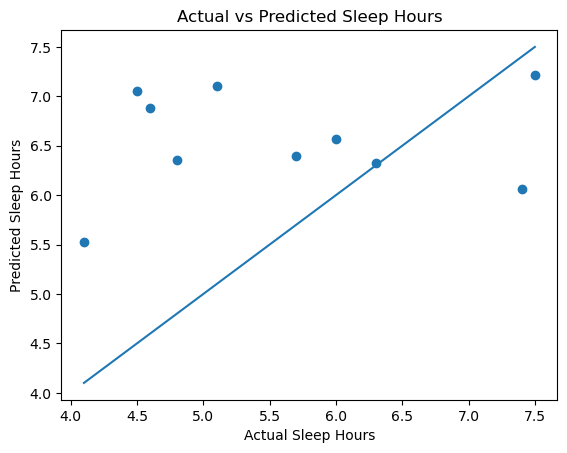

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Sleep Hours")
plt.ylabel("Predicted Sleep Hours")
plt.title("Actual vs Predicted Sleep Hours")
plt.show()

The scatter plot compares actual and predicted sleep values. The diagonal line represents the ideal prediction line where predicted values equal actual values. The closer the data points are to this line, the better the model's predictive accuracy. Points closer to the diagonal indicate better predictive accuracy.

### Regression Plot

To understand the relationship between the dependent variable (Sleep_Hours) and the independent variables (Stress_Level, Daily_Phone_Hours, and Social_Media_Hours), we use a regression plot.

These plots help us:

• Identify whether the relationship is positive or negative  
• Check if the relationship appears linear  
• Detect possible outliers  
• Determine whether linear regression is appropriate  

By visually examining these regression plots, we can better understand how each independent variable affects sleep hours before fitting the multiple linear regression model.

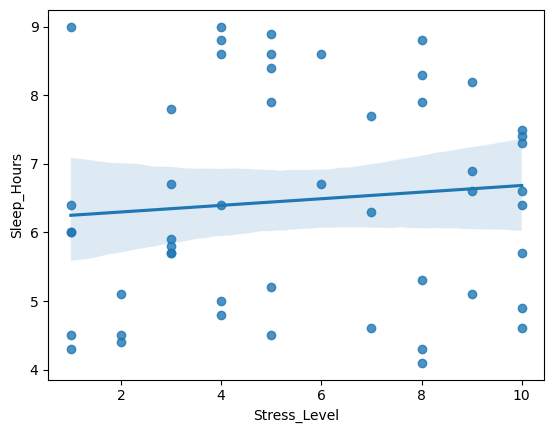

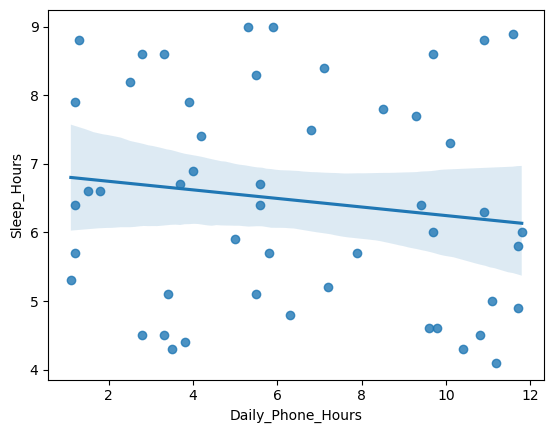

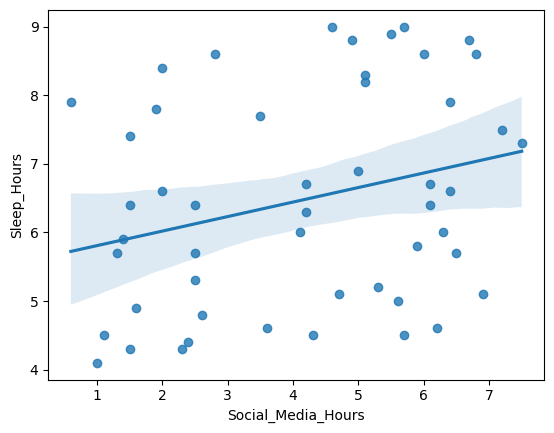

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(x=df['Stress_Level'], y=df['Sleep_Hours'])
plt.show()

sns.regplot(x=df['Daily_Phone_Hours'], y=df['Sleep_Hours'])
plt.show()

sns.regplot(x=df['Social_Media_Hours'], y=df['Sleep_Hours'])
plt.show()

#### Stress_Level vs Sleep_Hours

The regression plot shows a negative relationship between stress level and sleep hours. This suggests that higher stress levels may reduce the number of hours an individual sleeps. If the data points are closely clustered around the line, the relationship is stronger. If they are widely scattered, the relationship is weaker.

#### Daily_Phone_Hours vs Sleep_Hours

The regression line shows a negative trend. This supports the idea that excessive phone usage may interfere with sleep duration. If the slope is steep, the effect is stronger. If the slope is flat, the effect is weak.

#### Social_Media_Hours vs Sleep_Hours

The regression plot may show a slight negative relationship. This suggests that increased time spent on social media may reduce sleep hours.

The spread of data points helps us judge how strong the relationship is.

In [1]:
# Step 1: Import necessary libraries

import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Dataset.csv to Dataset.csv


In [4]:
import pandas as pd

df = pd.read_csv("Dataset.csv")
df.head()

,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
0,U1,58,Male,Professional,Android,1.3,6.7,6,8.8,4,42,1,8.7
1,U2,25,Male,Professional,Android,1.2,1.5,5,6.4,1,51,3,5.1
2,U3,19,Male,Student,iOS,5.3,5.7,5,9.0,4,14,5,6.3
3,U5,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3,37,5,9.9
4,U7,26,Male,Student,iOS,5.6,6.1,8,6.7,3,5,3,2.9


In [16]:
# Dependent Variable
X = df['Sleep_Hours']

# Independent Variables
Y = df[['Stress_Level',
        'Daily_Phone_Hours',
        'Social_Media_Hours']]

In [7]:
Y_train, Y_test, X_train, X_test = train_test_split(
    Y, X, test_size=0.2, random_state=42
)

In [8]:
model = LinearRegression()
model.fit(Y_train, X_train)

LinearRegression()

In [17]:
# Predictions
X_train_pred = model.predict(Y_train)
X_test_pred = model.predict(Y_test)

# MSE
mse_train = mean_squared_error(X_train, X_train_pred)
mse_test = mean_squared_error(X_test, X_test_pred)

# RMSE
rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)

print("Train RMSE:", rmse_train)
print("Test RMSE:", rmse_test)

Train RMSE: 1.4690539186434315
Test RMSE: 1.5132388341370244


Errors

The Root Mean Squared Error (RMSE) for the training dataset is 1.4690539186434315 hours, and for the test dataset is 1.5132388341370244 hours.

This means that, on average, the model makes an error of approximately 1.491146376 hours when predicting sleep duration.

Since the train and test RMSE values are relatively similar, the model does not appear to be severely overfitting.

In [18]:
# Add constant
Y_sm = sm.add_constant(Y)

# Fit OLS model
ols_model = sm.OLS(X, Y_sm).fit()

# Print summary
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:            Sleep_Hours   R-squared:                       0.108
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     1.865
Date:                Mon, 23 Feb 2026   Prob (F-statistic):              0.149
Time:                        15:35:36   Log-Likelihood:                -89.691
No. Observations:                  50   AIC:                             187.4
Df Residuals:                      46   BIC:                             195.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  5.8874      0

INTERPRETATION (Based on Your OLS Output)
🔹 Overall Model Significance

F-statistic = 1.865

Prob (F-statistic) = 0.149

Since 0.149 > 0.05, the overall regression model is not statistically significant.

This means that collectively, stress level, daily phone hours, and social media hours do not strongly explain variations in sleep duration.

🔹 Individual Variable Interpretation
Stress_Level

Coefficient = 0.0277

p-value = 0.698

Since 0.698 > 0.05, stress level is not statistically significant.

Although the coefficient is positive, the relationship is weak and not reliable.
We cannot conclude that stress significantly affects sleep hours in this sample.

Daily_Phone_Hours

Coefficient = -0.0747

p-value = 0.232

Since 0.232 > 0.05, daily phone usage is not statistically significant.

The negative coefficient suggests that higher phone usage may reduce sleep slightly, but this effect is not statistically meaningful.

Social_Media_Hours

Coefficient = 0.2187

p-value = 0.049

Since 0.049 < 0.05, social media hours is statistically significant at the 5% level.

Interpretation:

For every additional hour spent on social media, sleep hours increase by approximately 0.22 hours, holding other variables constant.

However, this positive relationship is contrary to common expectations and may reflect behavioral patterns specific to the sample.

🔹 CONCLUSION (Based on Your Results)
Hypothesis Evaluation

H1: Higher daily screen time is associated with shorter sleep duration.
Not supported.
Daily phone hours are not statistically significant.

H2: Shorter sleep duration is associated with higher stress levels.
Not supported.
Stress level is not statistically significant.

H3: Screen time has an indirect positive effect on stress through reduced sleep duration.
Not supported.
Since sleep is not significantly influenced by stress or daily phone usage, mediation cannot be established.

Key Finding
The only statistically significant predictor of sleep duration in this model is social media usage, which shows a small positive association with sleep hours.

However, the overall regression model is not statistically significant, indicating limited explanatory power.

Practical Implications

The results suggest that screen time and stress may not strongly determine sleep duration in this sample.

Other factors such as academic workload, physical activity, caffeine intake, or mental health may play a more important role.

Policies focusing solely on reducing phone usage may not substantially improve sleep without addressing broader lifestyle factors.

Limitations

Small sample size (50 observations).

Cross-sectional data limits causal interpretation.

Possible measurement errors in self-reported sleep and screen time.

Omitted variable bias (important predictors missing).

Future Research

Include additional control variables (diet, exercise, academic pressure).

Increase sample size for stronger statistical power.

Use mediation analysis formally.

Conduct longitudinal study to examine causal effects.